# Day 11 — Physical
### #30DayChartChallenge | April 2026

**The Physical Weight of E-Waste.** A circle-packing chart where each bubble's area scales to the millions of metric tons of electronic waste generated in 2022. Flags identify countries; numbers show the tonnage. China and the USA dominate, producing nearly 19 Mt combined.

**Data:** Global E-waste Monitor 2024 (UNITAR/ITU) via [globalewaste.org](https://globalewaste.org/map/)  
**Author:** Sharfudeen Yasar Arafath

In [1]:
# — packages ------------------------------------------------------------------

library(ggplot2)
library(dplyr)
library(packcircles)
library(showtext)
library(sysfonts)
library(ggimage)
library(countrycode)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'packcircles' was built under R version 4.5.3"
Loading required package: sysfonts

Loading required package: showtextdb

Warning message:
"package 'ggimage' was built under R version 4.5.3"
Warning message:
"package 'countrycode' was built under R version 4.5.3"


In [2]:
# — fonts & display size ------------------------------------------------------

font_add_google("Outfit", "outfit")
font_add_google("Roboto Condensed", "roboto_condensed")
font_add_google("JetBrains Mono", "jetbrains")
showtext_auto()
showtext_opts(dpi = 300)

options(repr.plot.width = 12, repr.plot.height = 10, repr.plot.res = 300)

In [3]:
# — read & process data -------------------------------------------------------

df <- read.csv("../../data/day_11/ewaste_data.csv", stringsAsFactors = FALSE)

# Circle packing layout (area proportional to e-waste amount)
packing <- circleProgressiveLayout(df$amount_mt, sizetype = "area")
df <- cbind(df, packing)

dat.gg <- circleLayoutVertices(packing, npoints = 100)
dat.gg$region <- df$region[dat.gg$id]

# Flags — sized to fill bubbles (no country name text, so flags can be bigger)
df$iso2 <- tolower(countrycode(df$country, "country.name", "iso2c"))
df$flag_url <- paste0("https://flagcdn.com/w160/", df$iso2, ".png")
plot_width <- max(dat.gg$x) - min(dat.gg$x)
df$flag_size <- (df$radius * 1.05) / plot_width

# Three tiers: amount-only labels (no country names — flags identify countries)
big   <- df %>% filter(radius > 0.8)
mid   <- df %>% filter(radius > 0.35 & radius <= 0.8)
small <- df %>% filter(radius > 0.22 & radius <= 0.35)

head(df)

,country,region,amount_mt,iso3,x,y,radius,iso2,flag_url,flag_size
,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
1,China,Asia,12.07,CHN,-1.9601021,0.000000,1.9601021,cn,https://flagcdn.com/w160/cn.png,0.20747581
2,USA,Americas,6.92,USA,1.4841511,0.000000,1.4841511,us,https://flagcdn.com/w160/us.png,0.15709664
3,India,Asia,4.14,IND,0.1586326,-2.273981,1.1479560,in,https://flagcdn.com/w160/in.png,0.12151056
4,Japan,Asia,2.64,JPN,0.1266760,1.980239,0.9166996,jp,https://flagcdn.com/w160/jp.png,0.09703218
5,Brazil,Americas,2.44,BRA,1.8902565,2.330322,0.8812923,br,https://flagcdn.com/w160/br.png,0.09328434
6,Russia,Europe,1.91,RUS,3.2648783,1.397908,0.7797255,ru,https://flagcdn.com/w160/ru.png,0.08253355


In [4]:
# — theme & palette -----------------------------------------------------------

bg       <- "#0a0e17"
txt      <- "#E6EDF3"
txt_dim  <- "#8B949E"
txt_cap  <- "#484F58"

region_colors <- c(
  "Asia"     = "#F43F5E",
  "Americas" = "#3B82F6",
  "Europe"   = "#10B981",
  "Africa"   = "#F59E0B",
  "Oceania"  = "#8B5CF6"
)

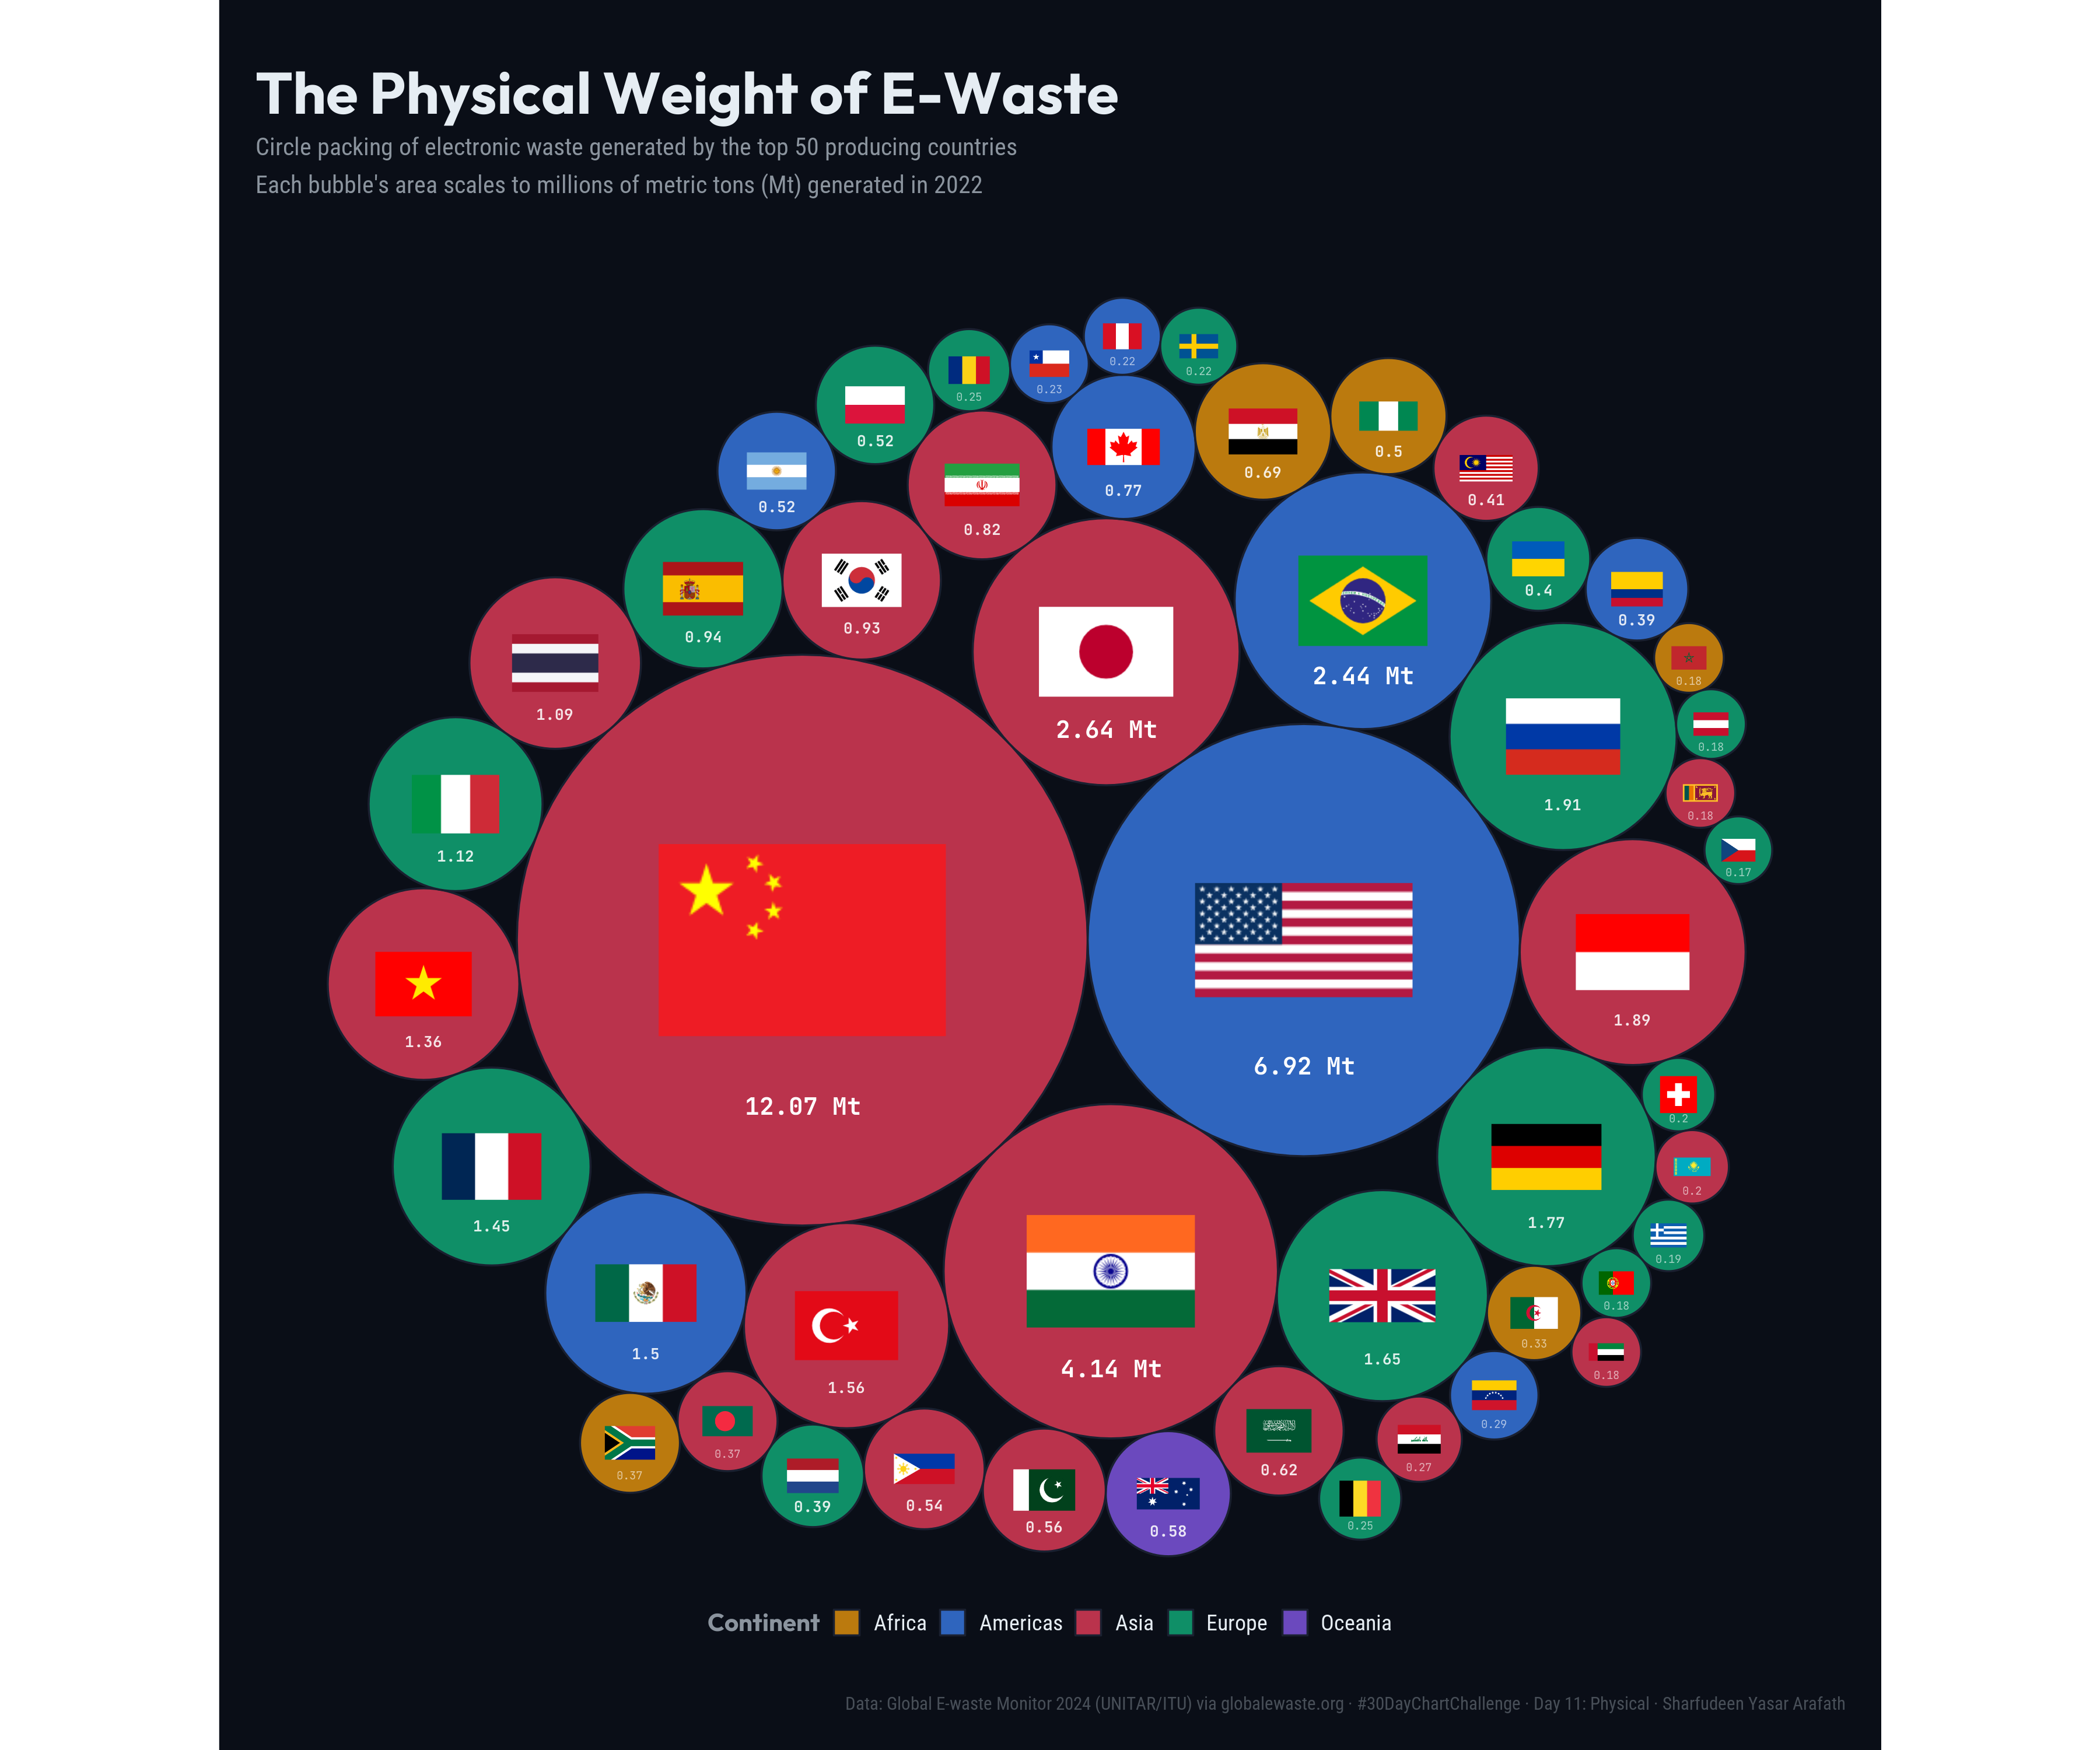

In [5]:
# — build the plot ------------------------------------------------------------

p <- ggplot() +

  # ─── packed bubbles ───
  geom_polygon(data = dat.gg,
    aes(x = x, y = y, group = id, fill = region),
    color = "#1a2030", alpha = 0.75, linewidth = 0.3) +

  # ─── country flags ───
  geom_image(data = df,
    aes(x, y, image = flag_url, size = I(flag_size))) +

  # ─── big bubbles: "X.X Mt" ───
  geom_text(data = big,
    aes(x, y - radius * 0.58, label = paste0(amount_mt, " Mt")),
    family = "jetbrains", fontface = "bold",
    size = 3.5, color = "#FFFFFF") +

  # ─── medium bubbles: just the number ───
  geom_text(data = mid,
    aes(x, y - radius * 0.6, label = amount_mt),
    family = "jetbrains", fontface = "bold",
    size = 2.2, color = "#FFFFFFDD") +

  # ─── small bubbles: tiny number ───
  geom_text(data = small,
    aes(x, y - radius * 0.65, label = amount_mt),
    family = "jetbrains", size = 1.6, color = "#FFFFFF99") +

  scale_fill_manual(values = region_colors) +
  coord_equal(clip = "off") +

  labs(
    title = "The Physical Weight of E-Waste",
    subtitle = paste0(
      "Circle packing of electronic waste generated by the top 50 producing countries\n",
      "Each bubble's area scales to millions of metric tons (Mt) generated in 2022"
    ),
    caption = paste0(
      "Data: Global E-waste Monitor 2024 (UNITAR/ITU) via globalewaste.org \u00b7 ",
      "#30DayChartChallenge \u00b7 Day 11: Physical \u00b7 ",
      "Sharfudeen Yasar Arafath"
    ),
    fill = "Continent"
  ) +

  theme_void(base_family = "roboto_condensed") +
  theme(
    plot.title = element_text(
      family = "outfit", face = "bold", size = 24,
      color = txt, margin = margin(t = 15, b = 5)),
    plot.subtitle = element_text(
      size = 10, color = txt_dim,
      lineheight = 1.3, margin = margin(b = 15)),
    plot.caption = element_text(
      size = 7.5, color = txt_cap, margin = margin(t = 20)),

    legend.position = "bottom",
    legend.direction = "horizontal",
    legend.title = element_text(
      family = "outfit", face = "bold", size = 10, color = txt_dim),
    legend.text = element_text(size = 9, color = txt),
    legend.key.size = unit(0.4, "cm"),
    legend.margin = margin(t = -10, b = 5),

    plot.background = element_rect(fill = bg, color = NA),
    panel.background = element_rect(fill = bg, color = NA),
    plot.margin = margin(15, 15, 15, 15)
  )

p

In [6]:
# — save ----------------------------------------------------------------------

ggsave("../../chart/day_11_physical.png",
       plot = p, width = 12, height = 10, dpi = 300, bg = bg)

cat("Done \u2014 saved to chart/day_11_physical.png\n")

Done — saved to chart/day_11_physical.png
